In [1]:
import torch
from torchvision.datasets import CIFAR10
from torchvision import transforms, models
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:

transform_cifar = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

transform_test = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
train_dataset = CIFAR10(root='./data', train=True, download=True, transform=transform_cifar)
test_dataset = CIFAR10(root='./data', train=False, download=True, transform=transform_test)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
print(f'CIFAR10: train {train_dataset.data.shape}, test {test_dataset.data.shape}')

CIFAR10: train (50000, 32, 32, 3), test (10000, 32, 32, 3)


In [7]:
print(f'CIFAR10: {train_dataset.classes}')

CIFAR10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


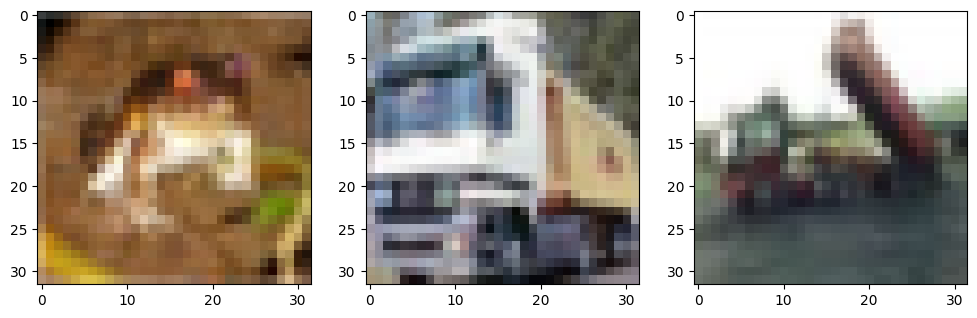

In [8]:
#show images
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(train_dataset.data[0], cmap='gray')
ax[1].imshow(train_dataset.data[1], cmap='gray')
ax[2].imshow(train_dataset.data[2], cmap='gray')
plt.show()


In [9]:
model = models.densenet121(weights="DEFAULT")

In [10]:
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [11]:
# modify the input and output layers
# model.features.conv0 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.classifier = nn.Linear(1024, 10)
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [12]:
lr = 0.001

model = model.to(device)
criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
best_val_loss = float('inf')
epochs = 20

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    tarin_bar = tqdm(train_loader, position=0, leave=True)
    for x, y in tarin_bar:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        class_pred = y_pred.argmax(dim=1)
        train_correct += class_pred.eq(y).sum().item()
    train_accuracy = train_correct / len(train_dataset)

    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_bar = tqdm(test_loader, position=0, leave=True)
    with torch.no_grad():
        for x, y in val_bar:
            x, y = x.to(device), y.to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y)
            val_loss += loss.item()
            class_pred = y_pred.argmax(dim=1)
            val_correct += class_pred.eq(y).sum().item()
    val_accuracy = val_correct / len(test_dataset)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        # torch.save(model.state_dict(), './model/DenseNet121_CIFAR.pth')
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.6f}, Train Acc: {train_accuracy:.6f}, Val Loss: {val_loss/len(test_loader):.6f}, Val Acc: {val_accuracy:.6f}')
  

100%|██████████| 157/157 [00:02<00:00, 71.33it/s]


Epoch 1/20, Train Loss: 0.974791, Train Acc: 0.663820, Val Loss: 0.725382, Val Acc: 0.752100


100%|██████████| 157/157 [00:02<00:00, 71.70it/s]


Epoch 2/20, Train Loss: 0.701068, Train Acc: 0.762240, Val Loss: 0.819525, Val Acc: 0.732000


 60%|██████    | 471/782 [00:21<00:14, 22.13it/s]


KeyboardInterrupt: 